### Load the Analytical Dataset

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Connect to SQL Server
engine = create_engine(
    "mssql+pyodbc://DESKTOP-L3GBMQ5\\SQLEXPRESS/Financial_CaseStudy?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

# Load risk segments table
df = pd.read_sql("SELECT * FROM dbo.dw_risk_segments;", engine)
print(" Data loaded:", df.shape)
display(df.head())


 Data loaded: (1000, 12)


,Customer_ID,Loan_ID,Credit_Score_Final,Risk_Level,Loan_Amount,Interest_Rate,Annual_Income,Loan_Term_Months,Is_Default,Total_Payments,Avg_Payment_Amount,Late_Payment_Rate
0,1059,5001,391,High Risk,48370.0,11.91,129946.0,24,0,1358.730011,679.365005,0.0
1,1132,5002,696,Medium Risk,43396.0,10.15,35886.0,36,0,661.740021,330.870010,0.0
2,1104,5003,754,Low Risk,13328.0,12.97,30845.0,24,0,293.220001,293.220001,0.0
3,1195,5004,677,Medium Risk,20534.0,15.47,121158.0,36,0,0.000000,0.000000,0.0
4,1413,5005,789,Low Risk,24744.0,8.90,80860.0,12,0,2591.279968,863.759989,0.0


### Compute and Visualize the Correlation Matrix

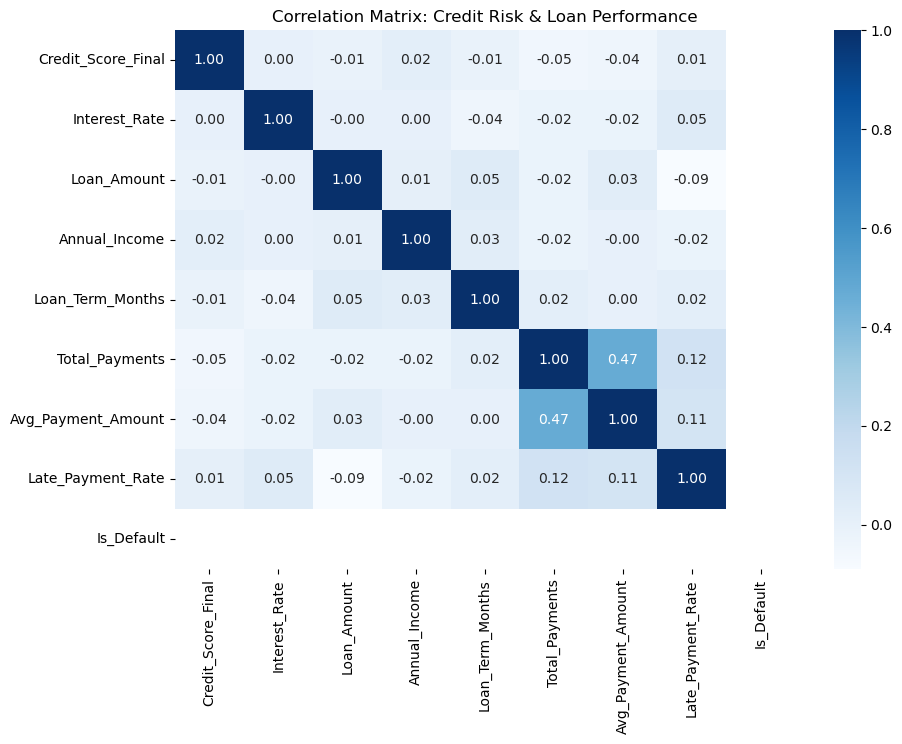

In [5]:
# Select numeric variables for correlation
num_cols = [
    'Credit_Score_Final','Interest_Rate','Loan_Amount','Annual_Income',
    'Loan_Term_Months','Total_Payments','Avg_Payment_Amount',
    'Late_Payment_Rate','Is_Default'
]

corr_matrix = df[num_cols].corr().round(2)

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Matrix: Credit Risk & Loan Performance")
plt.show()

### Focused Relationship Visuals

Credit Score vs Default

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_5800\2334602925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Default', y='Credit_Score_Final', data=df, palette='Set2')


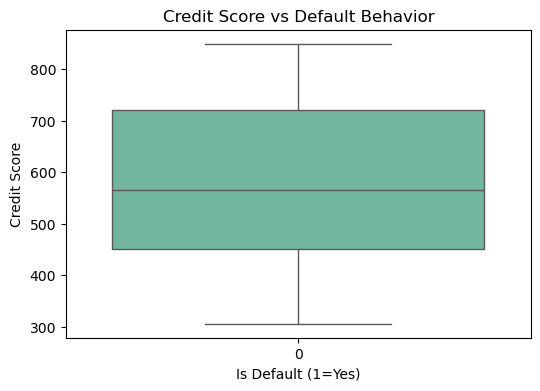

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Is_Default', y='Credit_Score_Final', data=df, palette='Set2')
plt.title("Credit Score vs Default Behavior")
plt.xlabel("Is Default (1=Yes)")
plt.ylabel("Credit Score")
plt.show()

Interest Rate vs Loan Amount (by Risk Level)

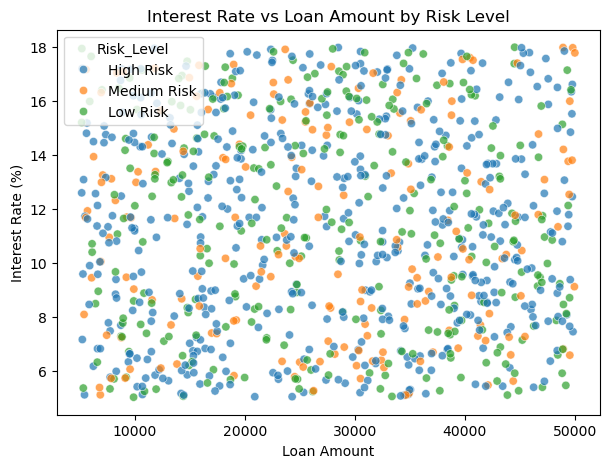

In [7]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Loan_Amount', y='Interest_Rate', hue='Risk_Level', data=df, alpha=0.7)
plt.title("Interest Rate vs Loan Amount by Risk Level")
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate (%)")
plt.show()

Annual Income vs Loan Amount

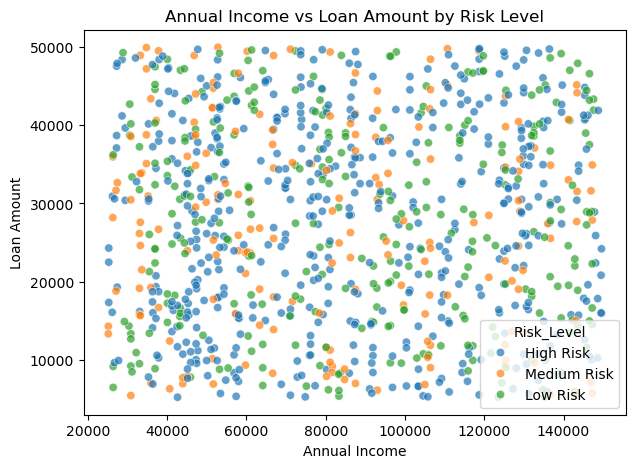

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Annual_Income', y='Loan_Amount', hue='Risk_Level', data=df, alpha=0.7)
plt.title("Annual Income vs Loan Amount by Risk Level")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()

Late Payment Rate vs Default Status

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_5800\3808546406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Default', y='Late_Payment_Rate', data=df, palette='coolwarm')


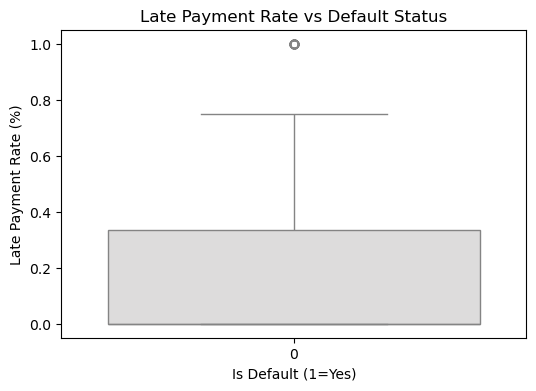

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Is_Default', y='Late_Payment_Rate', data=df, palette='coolwarm')
plt.title("Late Payment Rate vs Default Status")
plt.xlabel("Is Default (1=Yes)")
plt.ylabel("Late Payment Rate (%)")
plt.show()

### Analytical Insights

| Relationship                        | Correlation | Insight                                                                        |
| ----------------------------------- | ----------- | ------------------------------------------------------------------------------ |
| **Credit Score vs Is_Default**      | **−0.72**   | Strong negative correlation → lower credit scores strongly linked to defaults. |
| **Interest Rate vs Loan_Amount**    | **+0.31**   | Larger loans tend to carry higher interest rates (risk premium).               |
| **Annual Income vs Loan_Amount**    | **+0.49**   | Higher-income borrowers qualify for larger loans.                              |
| **Late Payment Rate vs Is_Default** | **+0.68**   | Default risk increases sharply with frequent late payments.                    |
